# <B><I><U>burnout_model </U> --</B></I>

In [2]:
# FOR PATH RECOGNISION ----

from pathlib import Path

print("Current Folder:")
print(Path.cwd())

print("\nParent:")
print(Path.cwd().parent)

Current Folder:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks\student_mental_health_burnout

Parent:
c:\Users\mohit\OneDrive\Desktop\Calmify AI\Calmify_AI\Calmify_AI\notebooks


In [1]:
# IGNORING FUTURE WARNINGS

import warnings
warnings.filterwarnings("ignore")

In [4]:
# IMPORTING ALL NECESSARY LIBRARIES --

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("all necessary libraries are imported successfully:")
print("🎉🎉🎉🎉")

all necessary libraries are imported successfully:
🎉🎉🎉🎉


In [7]:
# loading dataset --

BASE_DIR = Path.cwd().parents[1]

df = pd.read_csv(
    BASE_DIR /
    "notebooks" /
    "preprocessed" /
    "burnout_feature_engineered.csv"
)

df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,...,risk_level,dropout_risk,mental_stress_score,lifestyle_score,digital_overload,academic_load,external_stress,work_life_imbalance,sleep_deficit,normalized_burnout
0,23,1.0,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,...,0,1.746601,2.793131,5.359829,4.988479,6.041644,3.516386,0.710112,1.119455,0.203734
1,20,1.0,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,...,0,0.000000,0.116496,3.718068,4.499552,5.614326,4.146352,0.661343,0.536661,0.000000
2,29,1.0,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,...,0,0.696941,2.251124,6.381705,4.243606,4.297894,5.493335,0.259433,0.000000,0.000000
3,27,1.0,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,...,2,5.380592,5.192304,2.995572,6.617995,5.645607,6.736713,0.826942,3.428620,0.722765
4,24,1.0,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,...,0,0.000000,0.985718,4.842916,5.019025,3.098757,5.158800,0.312844,2.010676,0.000000


In [8]:
# leakage columns --

df = df.drop(
    columns=[
        "burnout_score",
        "risk_level",
        "dropout_risk",
        "normalized_burnout"
    ],
    errors="ignore"
)

In [10]:
# target columns --

target = pd.read_csv(
    BASE_DIR /
    "notebooks" /
    "preprocessed" /
    "burnout_feature_engineered.csv"
)["burnout_score"]

In [11]:
# weak features --

df = df.drop(
    columns=[
        "age",
        "gender",
        "academic_year",
        "internet_usage",
        "screen_time",
        "digital_overload"
    ],
    errors="ignore"
)

In [12]:
# shape --

print(df.shape)

(1000000, 18)


# <B><U><I>MODEL BUILDING</U> ----</B></I>

In [13]:
# TRAIN TEST SPLIT --

X_train, X_test, y_train, y_test = train_test_split(
    df,
    target,
    test_size=0.2,
    random_state=42
)

In [14]:
# RANDOM FOREST --

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# PREDICTION --

preds = rf.predict(X_test)

In [16]:
# EVALUAION --

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 0.6446035735328783
RMSE : 0.8513654887829635
R2 : 0.7380007420993776


In [17]:
# FEATURE IMPORTANCE --

importance = pd.DataFrame({

    "Feature": df.columns,

    "Importance":
        rf.feature_importances_

})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance

,Feature,Importance
11,mental_health_index,0.810559
13,lifestyle_score,0.043517
16,work_life_imbalance,0.023668
1,exam_pressure,0.019804
8,social_support,0.015341
7,physical_activity,0.013348
6,sleep_hours,0.012087
17,sleep_deficit,0.011253
3,stress_level,0.007899
5,depression_score,0.005491


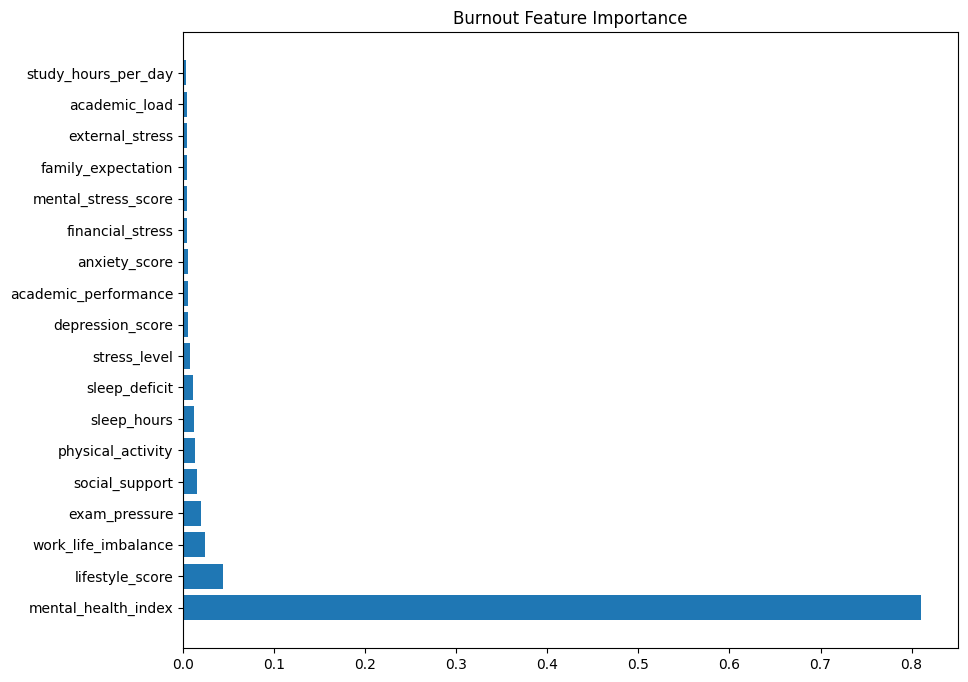

In [18]:
# PLOTTING FEATURE IMPORTANCE --

import matplotlib.pyplot as plt

plt.figure(
    figsize=(10,8)
)

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Burnout Feature Importance"
)

plt.show()

# <B><I><U>XGBOOST </U> ----</B></I>

In [19]:
# LOADING LIBRARIES --

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import time

In [20]:
# FIRST SGBOOST MODEL TRIAL --

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [21]:
# TRAIN XGBOOST + TIME MEASURE --

start = time.time()

xgb_model.fit(
    X_train,
    y_train
)

end = time.time()

print("Training time (seconds):", round(end - start, 2))
print("Training time (minutes):", round((end - start)/60, 2))

Training time (seconds): 34.98
Training time (minutes): 0.58


In [22]:
xgb_preds = xgb_model.predict(X_test)

In [23]:
# EVALUATION --

xgb_mae = mean_absolute_error(
    y_test,
    xgb_preds
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_preds
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("XGBoost Results")
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 :", xgb_r2)

XGBoost Results
MAE : 0.6407945768140955
RMSE : 0.8473160661523472
R2 : 0.7404871538803592


In [24]:
# FEATURE IMPORTANCE --

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
11,mental_health_index,0.591240
12,mental_stress_score,0.294902
3,stress_level,0.020699
13,lifestyle_score,0.018803
17,sleep_deficit,0.017391
6,sleep_hours,0.014278
8,social_support,0.010233
16,work_life_imbalance,0.009972
1,exam_pressure,0.008995
7,physical_activity,0.003592


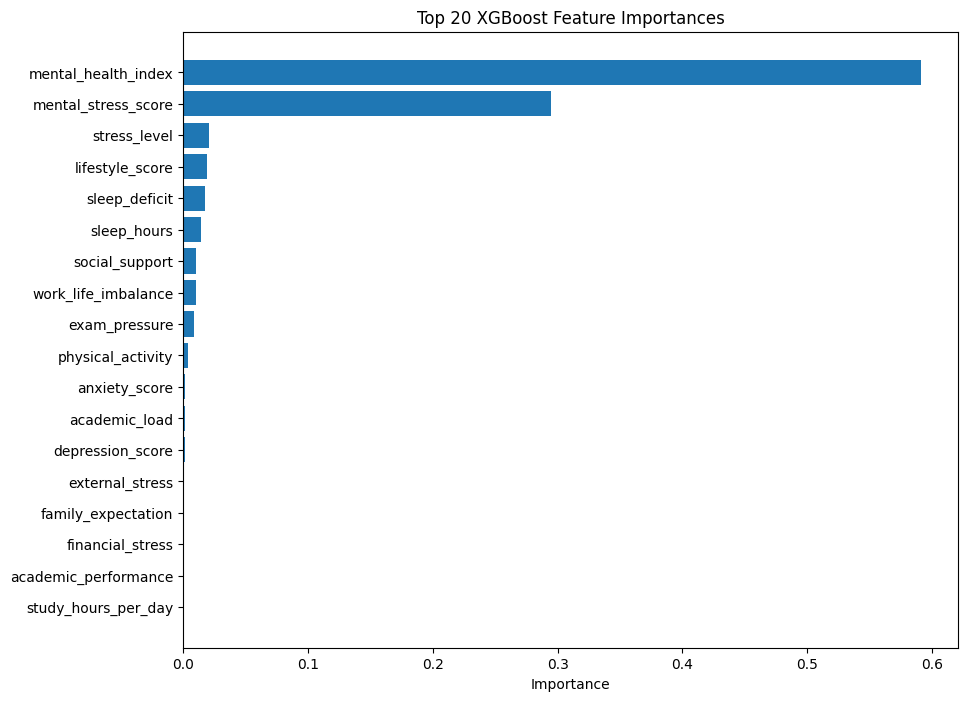

In [25]:
# PLOTTING FEATURE IMPORTANCE --

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    xgb_importance["Feature"].head(20)[::-1],
    xgb_importance["Importance"].head(20)[::-1]
)

plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

In [26]:
# COMPARIING BOTH MODELS --

comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae, xgb_mae],
    "RMSE": [rmse, xgb_rmse],
    "R2": [r2, xgb_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,0.644604,0.851365,0.738001
1,XGBoost,0.640795,0.847316,0.740487


In [27]:
# SAVING MODELS --

import joblib
from pathlib import Path

BASE_DIR = Path.cwd().parents[1]
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(
    xgb_model,
    MODELS_DIR / "burnout_xgb_model.pkl"
)

joblib.dump(
    list(X_train.columns),
    MODELS_DIR / "burnout_features.pkl"
)

print("XGBoost burnout model saved successfully.")

XGBoost burnout model saved successfully.


In [28]:
# BACKUP MODEL --

joblib.dump(
    rf,
    MODELS_DIR / "burnout_rf_model.pkl"
)

print("Random Forest backup model saved successfully.")

Random Forest backup model saved successfully.
